In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [2]:
dataset = 'model/point_history_classifier/point_history.csv'
model_save_path = 'model/point_history_classifier/point_history_classifier.keras'

# 分類数設定

In [3]:
NUM_CLASSES = 5

# 入力長

In [ ]:
TIME_STEPS = 10 # 8 green circles each finger tip
DIMENSION = 10 # 2 values (x,y) for each of the 5 fingers = 2*5 = 10

# 学習データ読み込み

In [5]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (TIME_STEPS * DIMENSION) + 1)))
# each line of the dataset point_history.csv starts with the finger number 0-4 followed by 160 values

In [6]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [ ]:
use_lstm = True
model = None

if use_lstm:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
        tf.keras.layers.Reshape((TIME_STEPS, DIMENSION), input_shape=(TIME_STEPS * DIMENSION, )), 
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(16, input_shape=[TIME_STEPS, DIMENSION]),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
else:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

C:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape            ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 80)              │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)              │         1,944 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)              │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)              │           250 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)               │            55 │
└─────────────────────────────────┴─────────────────────────┴───────────────┘

 Total params: 2,249 (8.79 KB)

 Trainable params: 2,249 (8.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [11]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step - accuracy: 0.1562 - loss: 1.6141
Epoch 1: saving model to model/point_history_classifier/point_history_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 703ms/step - accuracy: 0.1872 - loss: 1.5967 - val_accuracy: 0.1746 - val_loss: 1.5941
Epoch 2/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.1562 - loss: 1.5985
Epoch 2: saving model to model/point_history_classifier/point_history_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1818 - loss: 1.5912 - val_accuracy: 0.1905 - val_loss: 1.5883
Epoch 3/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1953 - loss: 1.5918
Epoch 3: saving model to model/point_history_classifier/point_history_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.1818 - loss: 1.5949 - val_accuracy: 0.2063 - val_loss: 1.5827
Epoch 4/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1953 - loss: 1.5711
Epoch 4: saving model to model/point_history_classifier/

In [13]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
[1.9456331e-03 2.1919189e-02 5.3682161e-06 9.7602355e-01 1.0632540e-04]
3


# 混同行列

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step 


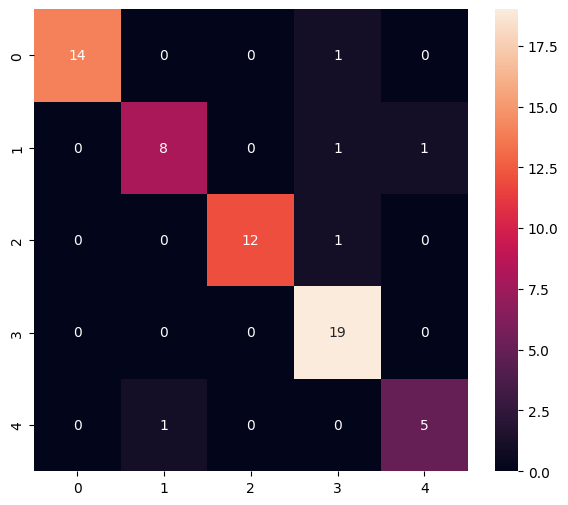

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.89      0.80      0.84        10
           2       1.00      0.92      0.96        13
           3       0.86      1.00      0.93        19
           4       0.83      0.83      0.83         6

    accuracy                           0.92        63
   macro avg       0.92      0.90      0.91        63
weighted avg       0.93      0.92      0.92        63



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
#converter.optimizations = [tf.lite.Optimize.DEFAULT] # old
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
]
tflite_quantized_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\Acer\AppData\Local\Temp\tmpcv1in9jm\assets


INFO:tensorflow:Assets written to: C:\Users\Acer\AppData\Local\Temp\tmpcv1in9jm\assets


Saved artifact at 'C:\Users\Acer\AppData\Local\Temp\tmpcv1in9jm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2175845700304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175871227984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175896582832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175871873648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175871874176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175877913888: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [17]:
tflite_save_path = 'model/point_history_classifier/point_history_classifier.tflite'

In [18]:
# モデルを変換(量子化
    # old
#converter = tf.lite.TFLiteConverter.from_keras_model(model)  # converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
#converter.optimizations = [tf.lite.Optimize.DEFAULT]
#converter.target_spec.supported_ops = [ # after adding all 5 fingers to training
#    tf.lite.OpsSet.TFLITE_BUILTINS,     # it tryes to do the training with a new
#]                                       # TensorFlow version, I need the system to adapt
    # new
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
]
# モデルを変換(量子化なし - 互換性のため)
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Acer\AppData\Local\Temp\tmpyx8ecrw6\assets


INFO:tensorflow:Assets written to: C:\Users\Acer\AppData\Local\Temp\tmpyx8ecrw6\assets


Saved artifact at 'C:\Users\Acer\AppData\Local\Temp\tmpyx8ecrw6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2175845700304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175871227984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175896582832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175871873648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175871874176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2175877913888: TensorSpec(shape=(), dtype=tf.resource, name=None)


11184

# 推論テスト

In [19]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

C:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [20]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(input_details)

[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 80], dtype=int32), 'shape_signature': array([-1, 80], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [21]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [22]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 3.06 ms


In [23]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.9456322e-03 2.1919195e-02 5.3682161e-06 9.7602355e-01 1.0632540e-04]
3
